Dataset Overview:
label
Positive    20
Negative    20
Name: count, dtype: int64

Total samples: 40

Train size: 30, Test size: 10

Feature matrix shape (train): (30, 145)
Feature matrix shape (test) : (10, 145)

MODEL 1: Naive Bayes (MultinomialNB)
Accuracy : 70.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.80      0.73         5
    Positive       0.75      0.60      0.67         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10

MODEL 2: Support Vector Machine (SVM)
Accuracy : 90.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.80      0.89         5
    Positive       0.83      1.00      0.91         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0

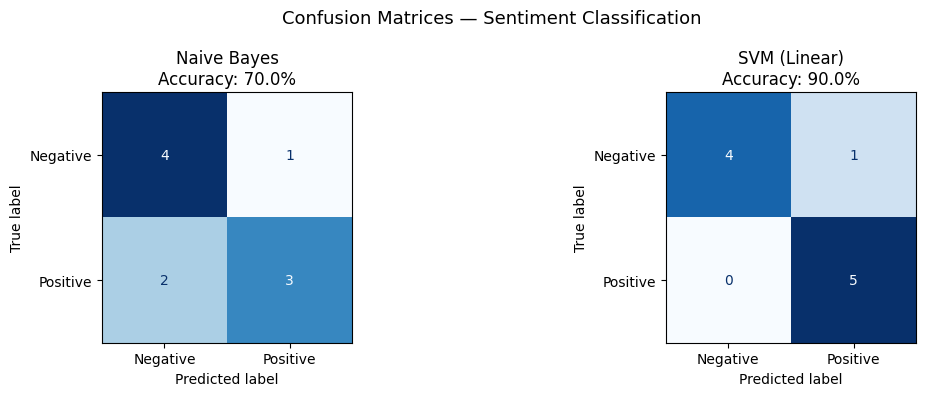

Saved: confusion_matrices.png


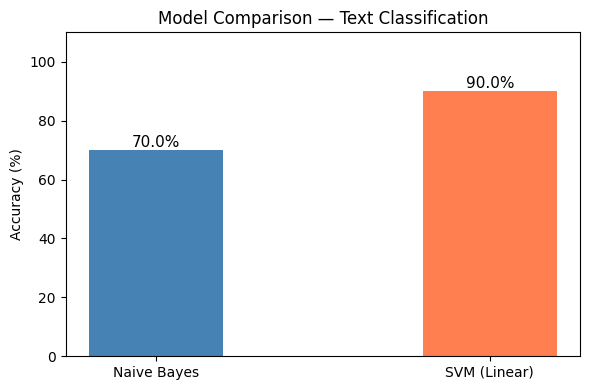

Saved: model_comparison.png


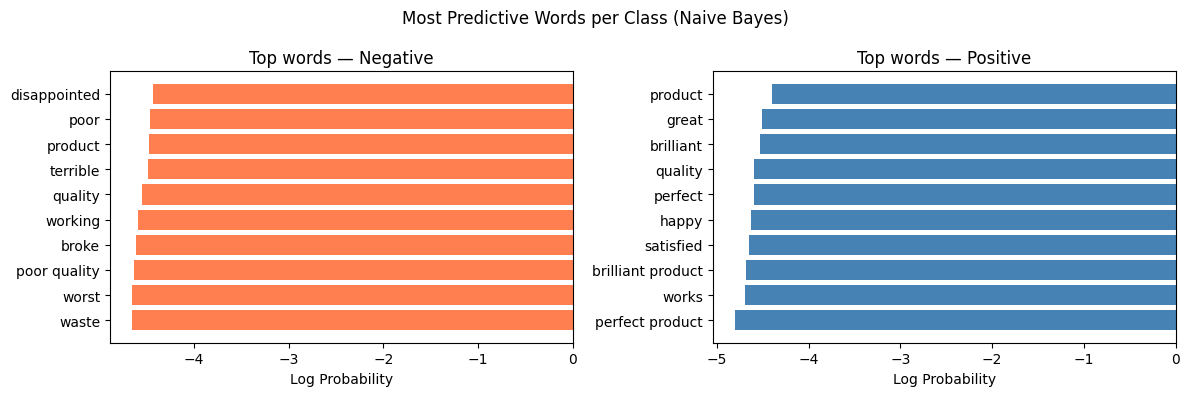

Saved: top_words.png

CUSTOM PREDICTION DEMO

Text                                                    NB          SVM     
--------------------------------------------------------------------------
This product is absolutely amazing, I love it        Positive     Positive  
Terrible quality, complete waste of money            Negative     Negative  
It is okay, nothing special                          Negative     Positive  
Best thing I ever bought, highly recommend           Positive     Positive  
Very bad experience, very disappointed               Negative     Negative  

           SUMMARY REPORT
  Task           : Sentiment Classification
  Dataset        : Custom (40 samples, 2 classes)
  Features       : TF-IDF (unigrams + bigrams)
  Train/Test     : 30 / 10
  Naive Bayes    : 70.00% accuracy
  SVM (Linear)   : 90.00% accuracy
  Best Model     : SVM


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

texts = [
    # Positive reviews
    "I love this product, it works perfectly",
    "Amazing quality, highly recommend to everyone",
    "Best purchase I have ever made, very happy",
    "Excellent service and fast delivery",
    "Great value for money, very satisfied",
    "This is fantastic, exceeded my expectations",
    "Wonderful experience, will buy again",
    "Outstanding product, works like a charm",
    "Very happy with this purchase, love it",
    "Superb quality, absolutely brilliant",
    "Really good product, does exactly what it says",
    "Impressive performance, very pleased",
    "Loved it, perfect for my needs",
    "Top notch quality, five stars",
    "Brilliant product, very well made",
    "Extremely satisfied, great product",
    "Works great, very happy customer",
    "Fantastic value, would recommend",
    "Perfect product, very well designed",
    "Incredible quality, totally worth it",

    # Negative reviews
    "Terrible product, complete waste of money",
    "Very disappointed, does not work at all",
    "Worst purchase ever, totally useless",
    "Poor quality, broke after one day",
    "Awful experience, never buying again",
    "This is garbage, do not buy it",
    "Horrible product, very bad quality",
    "Completely useless, very unhappy",
    "Waste of money, very poor quality",
    "Dreadful product, stopped working immediately",
    "Really bad, not worth the price",
    "Terrible quality, very disappointed",
    "Does not work, complete rubbish",
    "Very poor, broke within a week",
    "Awful quality, total waste",
    "Disgusting product, very bad experience",
    "Not working at all, very frustrated",
    "Cheap and nasty, avoid this product",
    "Broken on arrival, terrible service",
    "Worst product ever, extremely disappointed",
]

labels = [1]*20 + [0]*20   # 1=Positive, 0=Negative
label_names = ["Negative", "Positive"]

df = pd.DataFrame({"text": texts, "label": labels})
print("Dataset Overview:")
print(df["label"].value_counts().rename({1: "Positive", 0: "Negative"}))
print(f"\nTotal samples: {len(df)}\n")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"],
    test_size=0.25,       # 30 train, 10 test
    random_state=42,
    stratify=df["label"]
)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}\n")

# Feature Extraction — TF-IDF
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # unigrams + bigrams (e.g. "not good" captured together)
    max_features=500,
    stop_words="english"  # remove common words like "the", "a", "is"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Feature matrix shape (train): {X_train_tfidf.shape}")
print(f"Feature matrix shape (test) : {X_test_tfidf.shape}\n")

# Naive Bayes
print("=" * 50)
print("MODEL 1: Naive Bayes (MultinomialNB)")
print("=" * 50)

nb_model = MultinomialNB(alpha=1.0)   # alpha=1.0 is Laplace smoothing
nb_model.fit(X_train_tfidf, y_train)

nb_pred     = nb_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, nb_pred)

print(f"Accuracy : {nb_accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, nb_pred, target_names=label_names))

# SVM

print("=" * 50)
print("MODEL 2: Support Vector Machine (SVM)")
print("=" * 50)

svm_model = SVC(kernel="linear", C=1.0, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

svm_pred     = svm_model.predict(X_test_tfidf)
svm_accuracy = accuracy_score(y_test, svm_pred)

print(f"Accuracy : {svm_accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, svm_pred, target_names=label_names))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [nb_pred, svm_pred],
    ["Naive Bayes", "SVM (Linear)"]
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{title}\nAccuracy: {accuracy_score(y_test, preds)*100:.1f}%")

plt.suptitle("Confusion Matrices — Sentiment Classification", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()
print("Saved: confusion_matrices.png")

models_names = ["Naive Bayes", "SVM (Linear)"]
accuracies   = [nb_accuracy * 100, svm_accuracy * 100]

plt.figure(figsize=(6, 4))
bars = plt.bar(models_names, accuracies, color=["steelblue", "coral"], width=0.4)
plt.ylim(0, 110)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison — Text Classification")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{acc:.1f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("Saved: model_comparison.png")

feature_names = tfidf.get_feature_names_out()
log_probs     = nb_model.feature_log_prob_   # shape: (2, n_features)

top_n = 10
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cls_idx, (ax, cls_name) in enumerate(zip(axes, label_names)):
    top_indices = np.argsort(log_probs[cls_idx])[-top_n:]
    top_words   = [feature_names[i] for i in top_indices]
    top_scores  = log_probs[cls_idx][top_indices]
    ax.barh(top_words, top_scores, color="steelblue" if cls_idx == 1 else "coral")
    ax.set_title(f"Top words — {cls_name}")
    ax.set_xlabel("Log Probability")
plt.suptitle("Most Predictive Words per Class (Naive Bayes)", fontsize=12)
plt.tight_layout()
plt.savefig("top_words.png", dpi=150)
plt.show()
print("Saved: top_words.png")

print("\n" + "="*50)
print("CUSTOM PREDICTION DEMO")
print("="*50)

new_texts = [
    "This product is absolutely amazing, I love it",
    "Terrible quality, complete waste of money",
    "It is okay, nothing special",
    "Best thing I ever bought, highly recommend",
    "Very bad experience, very disappointed"
]

new_tfidf = tfidf.transform(new_texts)

print(f"\n{'Text':<50} {'NB':^12} {'SVM':^12}")
print("-" * 74)
for text, nb_p, svm_p in zip(new_texts,
                               nb_model.predict(new_tfidf),
                               svm_model.predict(new_tfidf)):
    nb_label  = label_names[nb_p]
    svm_label = label_names[svm_p]
    print(f"{text[:48]:<50} {nb_label:^12} {svm_label:^12}")

print("\n" + "="*50)
print("           SUMMARY REPORT")
print("="*50)
print(f"  Task           : Sentiment Classification")
print(f"  Dataset        : Custom (40 samples, 2 classes)")
print(f"  Features       : TF-IDF (unigrams + bigrams)")
print(f"  Train/Test     : 30 / 10")
print(f"  Naive Bayes    : {nb_accuracy*100:.2f}% accuracy")
print(f"  SVM (Linear)   : {svm_accuracy*100:.2f}% accuracy")
print(f"  Best Model     : {'SVM' if svm_accuracy >= nb_accuracy else 'Naive Bayes'}")
print("="*50)
